# Koo-lab models' held-out test set (LentiMPRA fold 10)

The koo standardized AlphaGenome encoder finetuned models (Agarwal et al. 2025
LentiMPRA) use **train = folds 2-9, val = fold 1, test = fold 10**. The exact
test split is bundled in
`/grid/koo/home/shared/data/lentimpra/agarwal_2025/{ct}_test10_val1.h5`
(`seq_test` 230 bp, `y_test` log-normalized MPRA activity, `x_test` one-hot).

This notebook loads that test set per cell type, organizes it into
`MoConsSwap_mpra/data/koo_test_set/`, and visualizes the measured-activity
distributions into `MoConsSwap_mpra/results/`.

In [1]:
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AGARWAL_DIR = Path("/grid/koo/home/shared/data/lentimpra/agarwal_2025")
CELL_TYPES = ["HepG2", "K562", "WTC11"]

OUT_DIR = Path(
    "/grid/koo/home/pmantill/projects/Virtual_Experiments/MoConsSwap_mpra/"
    "data/koo_test_set"
)
RESULTS_DIR = Path(
    "/grid/koo/home/pmantill/projects/Virtual_Experiments/MoConsSwap_mpra/results"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Each cell type kept fully separate (different test sets / sizes). The only
# join key carried is `test_idx` = the row position in this cell type's
# seq_test/y_test arrays in the h5 (its global index within that test set).
test = {}
for ct in CELL_TYPES:
    with h5py.File(AGARWAL_DIR / f"{ct}_test10_val1.h5", "r") as f:
        seq = [s.decode() for s in f["seq_test"][:]]
        y = f["y_test"][:].astype(np.float32)
    df_ct = pd.DataFrame({
        "test_idx": np.arange(len(seq), dtype=np.int64),
        "sequence": seq,
        f"{ct}_measured": y,
    })
    assert (df_ct["sequence"].str.len() == 230).all()
    test[ct] = df_ct
    out = OUT_DIR / f"{ct}_test10_lib.csv"
    df_ct.to_csv(out, index=False)
    print(f"{ct}: {len(df_ct)} test seqs  "
          f"y[min,mean,max]=[{y.min():.3f},{y.mean():.3f},{y.max():.3f}]  -> {out.name}")

HepG2: 12298 test seqs  y[min,mean,max]=[-2.265,-0.222,4.410]  -> HepG2_test10_lib.csv
K562: 19670 test seqs  y[min,mean,max]=[-1.602,-0.103,2.838]  -> K562_test10_lib.csv
WTC11: 4622 test seqs  y[min,mean,max]=[-4.205,-0.573,4.126]  -> WTC11_test10_lib.csv


wrote /grid/koo/home/pmantill/projects/Virtual_Experiments/MoConsSwap_mpra/results/test_set_activity_dist.png


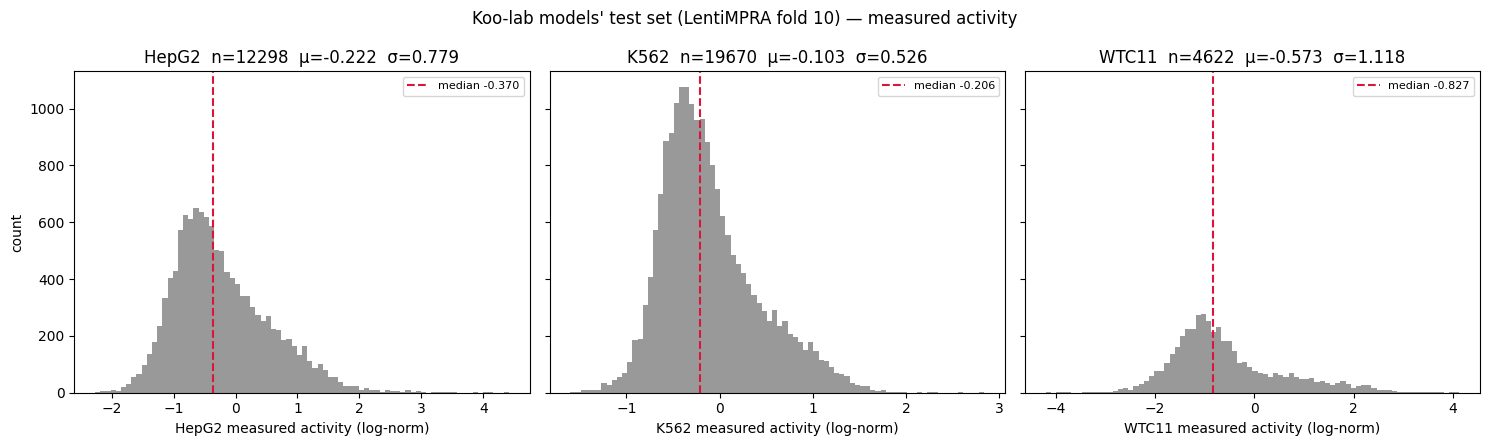

In [2]:
# Measured-activity distribution of the held-out test set, per cell type.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, ct in zip(axes, CELL_TYPES):
    y = test[ct][f"{ct}_measured"].values
    ax.hist(y, bins=80, color="0.6", edgecolor="none")
    ax.axvline(np.median(y), color="crimson", lw=1.5, ls="--",
               label=f"median {np.median(y):.3f}")
    ax.set_xlabel(f"{ct} measured activity (log-norm)")
    ax.set_title(f"{ct}  n={len(y)}  \u03bc={y.mean():.3f}  \u03c3={y.std():.3f}")
    ax.legend(fontsize=8)
axes[0].set_ylabel("count")
fig.suptitle("Koo-lab models' test set (LentiMPRA fold 10) \u2014 measured activity")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "test_set_activity_dist.png", dpi=150, bbox_inches="tight")
print("wrote", RESULTS_DIR / "test_set_activity_dist.png")
plt.show()

In [4]:
# Equal-size activity bins on the TEST set's measured activity, per cell type.
# These bins do NOT cover the full test set (repressing = lowest N_BIN, activating
# = highest N_BIN, neutral = N_BIN centered on the median); rest left unbinned.
# Cell types stay fully separate.
# =====================================================================
N_BIN = 300           # seqs per bin (you'll randomly draw N_PER_BIN of these later)
# =====================================================================

LABELS = ["repressing", "neutral", "activating"]
BOUNDS = {}
for ct in CELL_TYPES:
    s = test[ct][f"{ct}_measured"]
    v = s.dropna()
    n = len(v)
    f = N_BIN / n
    rep_hi = v.quantile(f)
    neu_lo = v.quantile(0.5 - f / 2)
    neu_hi = v.quantile(0.5 + f / 2)
    act_lo = v.quantile(1 - f)
    BOUNDS[ct] = dict(rep_hi=float(rep_hi), neu_lo=float(neu_lo),
                      neu_hi=float(neu_hi), act_lo=float(act_lo))

    cat = pd.Series(pd.NA, index=s.index, dtype="object")
    cat[s < rep_hi] = "repressing"
    cat[(s >= neu_lo) & (s < neu_hi)] = "neutral"
    cat[s >= act_lo] = "activating"
    test[ct][f"{ct}_actbin"] = pd.Categorical(cat, categories=LABELS)

    counts = test[ct][f"{ct}_actbin"].value_counts().reindex(LABELS)
    print(f"{ct}: rep<{rep_hi:.4f}  neu[{neu_lo:.4f},{neu_hi:.4f})  "
          f"act>={act_lo:.4f}")
    print("   " + "  ".join(f"{b}={counts[b]}" for b in LABELS)
          + f"  (unbinned={test[ct][f'{ct}_actbin'].isna().sum()})")

HepG2: rep<-1.4280  neu[-0.3890,-0.3470)  act>=1.5292
   repressing=300  neutral=300  activating=300  (unbinned=11398)
K562: rep<-0.9810  neu[-0.2150,-0.1980)  act>=1.2650
   repressing=295  neutral=302  activating=303  (unbinned=18770)
WTC11: rep<-1.9090  neu[-0.8950,-0.7590)  act>=1.5235
   repressing=299  neutral=300  activating=300  (unbinned=3723)


In [5]:
# Randomly build a measured-activity-stratified sub-library per cell type from
# the chosen bins. Kept fully separate per cell type; `test_idx` is preserved so
# rows map back to the h5 test arrays.
# =====================================================================
# EDIT THESE:
PICK_BINS   = ["repressing", "neutral", "activating"]  # which bins to draw from
N_PER_BIN   = 100           # sequences sampled per bin per cell type
SEED        = 0             # reproducible RNG
STRAT_DIR   = OUT_DIR / "stratified_libs"
# =====================================================================
STRAT_DIR.mkdir(parents=True, exist_ok=True)

test_strat = {}
for ct in CELL_TYPES:
    parts = []
    for lab in PICK_BINS:
        pool = test[ct][test[ct][f"{ct}_actbin"] == lab]
        take = min(N_PER_BIN, len(pool))
        if take < N_PER_BIN:
            print(f"  ! {ct}/{lab}: only {len(pool)} avail, taking {take}")
        parts.append(pool.sample(n=take, random_state=SEED))
    sub = (pd.concat(parts)
             .sample(frac=1, random_state=SEED)   # shuffle bin order
             .reset_index(drop=True))
    test_strat[ct] = sub
    out = STRAT_DIR / f"{ct}_test10_stratified_lib.csv"
    sub.to_csv(out, index=False)
    n_by = sub[f"{ct}_actbin"].value_counts().reindex(PICK_BINS)
    print(f"{ct}: {len(sub)} seqs -> {out.name}  "
          + "  ".join(f"{b}={n_by[b]}" for b in PICK_BINS))

HepG2: 300 seqs -> HepG2_test10_stratified_lib.csv  repressing=100  neutral=100  activating=100
K562: 300 seqs -> K562_test10_stratified_lib.csv  repressing=100  neutral=100  activating=100
WTC11: 300 seqs -> WTC11_test10_stratified_lib.csv  repressing=100  neutral=100  activating=100
